# データ読込

In [1]:
# ローカルユーティリティ: 外部ディレクトリ(utils, logic)への依存を排除
import pandas as pd
import sqlite3
from datetime import datetime, date, timedelta
from typing import Union, List
import jpholiday

# 日本の祝日取得（jpholiday が無ければ空集合）
def get_japanese_holidays(
    start: Union[str, date], end: Union[str, date], as_str: bool = True
) -> Union[List[str], List[date]]:
    """
    指定した期間の日本の祝日を取得する関数。

    Args:
        start (str or date): 開始日（"YYYY-MM-DD" または date型）
        end (str or date): 終了日（"YYYY-MM-DD" または date型）
        as_str (bool): Trueなら"YYYY-MM-DD"形式、Falseならdate型

    Returns:
        Union[List[str], List[date]]: 祝日のリスト（文字列またはdate型）
    """
    # --- 日付型でなければ変換 ---
    if isinstance(start, str):
        start = datetime.strptime(start, "%Y-%m-%d").date()
    if isinstance(end, str):
        end = datetime.strptime(end, "%Y-%m-%d").date()

    # --- 日付範囲の祝日抽出 ---
    holidays = [
        d
        for d in (start + timedelta(days=i) for i in range((end - start).days + 1))
        if jpholiday.is_holiday(d)
    ]

    return [d.strftime("%Y-%m-%d") for d in holidays] if as_str else holidays

# 日本語フォント設定（存在する最初の候補を適用）
def set_jp_font():
    try:
        import matplotlib.pyplot as plt
        from matplotlib import font_manager
        candidates = ["IPAexGothic", "IPAGothic", "Noto Sans CJK JP", "TakaoGothic"]
        system_fonts = font_manager.findSystemFonts()
        for cand in candidates:
            for f in system_fonts:
                if cand in f:
                    plt.rcParams["font.family"] = cand
                    return
    except Exception:
        pass  # フォント設定失敗は無視

# SQLite から重量データを読む（テーブル名は推測。存在するテーブルに合わせて変更可）
def load_data_from_sqlite(db_path="/work/app/data/factory_manage/weight_data.db", table_name="weight_data"):
    with sqlite3.connect(db_path) as conn:
        # テーブル存在チェック & 自動選択
        try:
            df_tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'", conn)
            if table_name not in df_tables['name'].tolist() and len(df_tables):
                # 最初のテーブルを利用
                table_name_local = df_tables['name'].iloc[0]
            else:
                table_name_local = table_name
        except Exception:
            table_name_local = table_name
        df_local = pd.read_sql(f"SELECT * FROM {table_name_local}", conn)
    # 日付カラム推測
    for col in ["伝票日付", "date", "dt"]:
        if col in df_local.columns:
            try:
                df_local[col] = pd.to_datetime(df_local[col])
            except Exception:
                pass
    return df_local

set_jp_font()
print("[INFO] ローカルユーティリティを読み込みました。")

# モジュールキャッシュのクリア（new_model1/new_model2 が部分的に読み込まれている場合に対応）
import sys, importlib
for name in list(sys.modules.keys()):
    if name.startswith('new_model1') or name.startswith('new_model2'):
        del sys.modules[name]
# 足りなければ /works/scripts を先頭に追加してからロード
sys.path.insert(0, '/works/scripts')
try:
    import new_model1
    importlib.reload(new_model1)
    print('reloaded new_model1 from', getattr(new_model1, '__file__', None))
except Exception as e:
    print('reload new_model1 failed:', e)
try:
    import new_model2
    importlib.reload(new_model2)
    print('reloaded new_model2 from', getattr(new_model2, '__file__', None))
except Exception as e:
    print('reload new_model2 failed:', e)

[INFO] ローカルユーティリティを読み込みました。
reloaded new_model1 from /works/scripts/new_model1/__init__.py
reloaded new_model2 from /works/scripts/new_model2/__init__.py
reloaded new_model1 from /works/scripts/new_model1/__init__.py
reloaded new_model2 from /works/scripts/new_model2/__init__.py


In [2]:
import pandas as pd
# from logic.factory_manage.utils.sql import load_data_from_sqlite  # 外部依存 -> ローカル版へ
# from utils.get_holydays import get_japanese_holidays             # 外部依存 -> ローカル版へ

# from utils.font import set_jp_font  # 外部フォント設定 -> ローカル版
# set_jp_font()  # 既に前セルで実行済み

# CSV / DB 読み込み（パスはPRE_HANNNYU配下に限定）
# path = "/works/data/factory_manage/weight_data.db"  # そのまま利用

# df = load_data_from_sqlite(path)
# df["伝票日付"].max()
# df.head()

### 2021年～

In [3]:
# pdは既にCELL INDEX:1でimportされているので、そのまま使えます
df_2021 = pd.read_csv("/works/data/input/2020顧客.csv", encoding="utf-8")
df_2022 = pd.read_csv("/works/data/input/2022顧客.csv", encoding="utf-8")
df_2023 = pd.read_csv("/works/data/input/2023_all.csv", encoding="utf-8")
df_2024 = pd.read_csv("/works/data/input/20240501-20250422.csv", encoding="utf-8")

df_2021 = df_2021[['伝票日付', '商品', '正味重量']]
df_2022 = df_2022[['伝票日付', '商品', '正味重量']]
df_2023 = df_2023[['伝票日付', '商品', '正味重量']]
df_2021.rename(columns={'商品': '品名'}, inplace=True)
df_2022.rename(columns={'商品': '品名'}, inplace=True)
df_2023.rename(columns={'商品': '品名'}, inplace=True)
df_2024 = df_2024[['伝票日付', '品名', '正味重量']]

df_all = pd.concat([df_2021, df_2022, df_2023, df_2024], ignore_index=True)
# 曜日など () を削除
df_all["伝票日付"] = df_all["伝票日付"].str.replace(r"\(.*\)", "", regex=True)
df_all["伝票日付"] = pd.to_datetime(df_all["伝票日付"], format="%Y/%m/%d")
df_all


/tmp/ipykernel_21785/1970061802.py:4: DtypeWarning: Columns (68) have mixed types. Specify dtype option on import or set low_memory=False.
  df_2023 = pd.read_csv("/works/data/input/2023_all.csv", encoding="utf-8")


,伝票日付,品名,正味重量
0,2020-01-04,混合廃棄物A,870.0
1,2020-01-04,混合廃棄物A,450.0
2,2020-01-04,混合廃棄物（焼却物）,2400.0
3,2020-01-04,混合廃棄物A,250.0
4,2020-01-04,混合廃棄物A,800.0
...,...,...,...
184245,2025-05-26,軽量物系A(ｽﾀｲﾛﾌｫｰﾑ),10.0
184246,2025-05-26,廃ﾌﾟﾗｽﾁｯｸ類,30.0
184247,2025-05-26,廃ﾌﾟﾗｽﾁｯｸ類,160.0
184248,2025-05-26,混合廃棄物A,2530.0


### 予約情報

In [4]:
df_reserve = pd.read_csv(
    "/works/data/input/yoyaku_data.csv")
df_reserve["予約日"] = pd.to_datetime(df_reserve["予約日"])
df_reserve.rename(columns={"台数": "予約台数"}, inplace=True)
print(df_reserve["予約日"].min(), df_reserve["予約日"].max())
print(df_reserve.columns)
df_reserve

2023-01-04 00:00:00 2025-05-31 00:00:00
Index(['予約日', '予約得意先名', '固定客', '予約台数'], dtype='object')


,予約日,予約得意先名,固定客,予約台数
0,2023-01-04,アンデス,False,1.0
1,2023-01-04,リサイクルレスキュー,False,1.0
2,2023-01-04,山口興業,False,2.0
3,2023-01-04,明和建装,False,1.0
4,2023-01-04,まごころ清掃社,False,1.0
...,...,...,...,...
45726,2025-05-31,首都高メンテナンス,False,1.0
45727,2025-05-31,シミズオクト,False,1.0
45728,2025-05-31,鈴亀,False,1.0
45729,2025-05-31,鈴木運輸,True,1.0


### 受入番号用

In [5]:
import os
import glob
import pandas as pd

# ディレクトリ内の全CSVファイルパスを取得
csv_dir = "/works/data/input/受入_時刻"
csv_files = glob.glob(os.path.join(csv_dir, "*.csv"))

# 全CSVを読み込んで結合
dfs = []
for f in csv_files:
    df_tmp = pd.read_csv(f)

    # 伝票日付を整形 → 日付型へ変換
    df_tmp["伝票日付"] = df_tmp["伝票日付"].str.replace(r"\(.*?\)", "", regex=True).str.strip()
    df_tmp["伝票日付"] = pd.to_datetime(df_tmp["伝票日付"], format="%Y/%m/%d")

    # 正味重量をカンマ除去して数値化
    df_tmp["正味重量"] = df_tmp["正味重量"].replace({',': ''}, regex=True).astype(float)

    # 受入番号の欠損を埋めて型変換（念のため）
    df_tmp["受入番号"] = df_tmp["受入番号"].fillna(-1).astype(int)

    dfs.append(df_tmp)

df_Ukeire = pd.concat(dfs, ignore_index=True)

# 必要カラムだけ抽出（品名・重量・受入番号）
df_Ukeire = df_Ukeire[["伝票日付", "品名", "正味重量", "受入番号"]].copy()

# 台数カウント準備（日付・品名ごとの受入番号ユニーク数）
df_count = (
    df_Ukeire.groupby(["伝票日付", "品名"])["受入番号"]
    .nunique()
    .reset_index()
    .rename(columns={"受入番号": "台数"})
)

# （参考）結合しておく場合
df_merged = pd.merge(df_Ukeire, df_count, on=["伝票日付", "品名"], how="left")

# リネーム
df_merged.rename(columns={"台数": "搬入済台数"}, inplace=True)

# 結果確認
df_merged


,伝票日付,品名,正味重量,受入番号,搬入済台数
0,2025-06-01,混合廃棄物A,1110.0,54050,35
1,2025-06-01,混合廃棄物A,120.0,54094,35
2,2025-06-01,混合廃棄物A,270.0,54060,35
3,2025-06-01,混合廃棄物A,1220.0,54044,35
4,2025-06-01,混合廃棄物A,1650.0,54089,35
...,...,...,...,...,...
64680,2024-11-30,混合廃棄物A,50.0,31824,74
64681,2024-11-30,混合廃棄物A,310.0,31822,74
64682,2024-11-30,混合廃棄物A,1140.0,31805,74
64683,2024-11-30,木くず,870.0,31824,9


In [6]:
target_items = ["混合廃棄物A", "混合廃棄物B", "GC 軽鉄･ｽﾁｰﾙ類", "選別", "木くず"]

# 成功・モデル

## 予約数の追加モデル

In [14]:
# new_model1: PRE_HANNNYU/scripts/new_model1 内のローカルモジュールを動的パス追加で利用

import sys, os
SCRIPT_ROOT = "/works/scripts"
if SCRIPT_ROOT not in sys.path:
    sys.path.append(SCRIPT_ROOT)

# robust import

from new_model1 import full_walkforward, ReserveFeatureBuilder


import pandas as pd
from sklearn.metrics import r2_score, mean_absolute_error
import matplotlib.pyplot as plt


In [24]:

# default: do not run full heavy pipeline unless explicitly enabled
RUN_PIPELINE = True

# 閾値（暫定的に緩和して予測生成が行われるか確認）
MIN_STAGE1_DAYS = 20  # 元:30
MIN_STAGE2_DAYS = 10  # 元:15

if RUN_PIPELINE:
    # 予約特徴量生成
    df_reserve_feat = ReserveFeatureBuilder(df_reserve).build()

    # 対象日を予約日に限定 (学習データが足りない場合はこのフィルタを緩めることを検討)
    reserve_dates = df_reserve_feat.index
    df_all["伝票日付"] = pd.to_datetime(df_all["伝票日付"])
    df_all = df_all[df_all["伝票日付"].isin(reserve_dates)].copy()

    print("[DEBUG] reservation_filtered_days=", df_all["伝票日付"].nunique())
    print("[DEBUG] reservation_span=", df_all["伝票日付"].min(), "->", df_all["伝票日付"].max())

    # 評価日数
    days_list = [300]
    results = []
    for days in days_list:
        print(f"\n=== {days}日分のデータで評価中 ===")
        latest_date = df_all["伝票日付"].max()
        cutoff_date = latest_date - pd.Timedelta(days=days)
        df_subset = df_all[df_all["伝票日付"] >= cutoff_date].copy()
        hol_max = df_subset["伝票日付"].max()
        hol_min = df_subset["伝票日付"].min()
        holidays = get_japanese_holidays(hol_min, hol_max)
        print("[DEBUG] df_subset_days=", df_subset["伝票日付"].nunique(), "range=", hol_min, "->", hol_max)
        try:
            actual, pred = full_walkforward(
                df_subset,
                holidays=holidays,
                df_reserve=df_reserve,
                min_stage1_days=MIN_STAGE1_DAYS,
                min_stage2_days=MIN_STAGE2_DAYS,
                top_n=2,
            )
            print(f"[DEBUG] returned_lengths actual={len(actual) if isinstance(actual, list) else 'NA'} pred={len(pred) if isinstance(pred, list) else 'NA'}")
            if isinstance(actual, list) and isinstance(pred, list) and len(actual) > 0 and len(pred) > 0:
                r2 = r2_score(actual, pred)
                mae = mean_absolute_error(actual, pred)
                results.append((days, r2, mae))
                print(f"✅ R² = {r2:.3f}, MAE = {mae:,.0f}kg")
            else:
                print("⚠ 評価に十分なデータがありません (予測件数0)")
                results.append((days, None, None))
        except Exception as e:
            print(f"❌ エラー: {e}")
            results.append((days, None, None))

    # 結果表示
    import pandas as pd

    df_result = pd.DataFrame(results, columns=["days", "R2", "MAE"])
    print("\n=== 評価結果 ===")
    print(df_result)
    if df_result["R2"].notna().any():
        plt.plot(df_result["days"], df_result["R2"], marker="o")
        plt.xlabel("Days")
        plt.ylabel("R² Score")
        plt.title("日数別 R² 評価 (new_model1)")
        plt.grid(True)
        plt.show()
else:
    print('Imports successful. To run pipeline, set RUN_PIPELINE = True in this cell.')


[DEBUG] reservation_filtered_days= 761
[DEBUG] reservation_span= 2023-01-04 00:00:00 -> 2025-05-26 00:00:00

=== 300日分のデータで評価中 ===
[DEBUG] df_subset_days= 280 range= 2024-07-30 00:00:00 -> 2025-05-26 00:00:00
❌ エラー: full_walkforward() missing 1 required positional argument: 'df_weather'

=== 評価結果 ===
   days    R2   MAE
0   300  None  None


## 天気追加モデル

[INFO] using WeatherFeatureBuilder from new_model2.feature_builder

=== 90日分のデータで評価中 (weather) ===
[DEBUG] hol_min, hol_max = 2025-02-25 00:00:00 2025-05-26 00:00:00
[DEBUG] reserve_raw_rows=4773 range=2025-02-25 00:00:00->2025-05-26 00:00:00
[Weather] fetch 2025-02-25 -> 2025-05-26
[Weather] final params start_date=2025-02-25 end_date=2025-05-26
[Weather] status=200 url=https://archive-api.open-meteo.com/v1/archive?latitude=35.6895&longitude=139.6917&start_date=2025-02-25&end_date=2025-05-26&daily=temperature_2m_mean&daily=precipitation_sum&timezone=Asia%2FTokyo
[Weather] rows=91 cols=['平均気温', '降水量', '天気_大雨', '天気_晴れ', '天気_雨', '天気_台風']
[DEBUG] weather_rows=91 range=2025-02-25 00:00:00->2025-05-26 00:00:00
▶️ full_walkforward(new_model2) 開始
[DEBUG] target_items=['混合廃棄物A', '混合廃棄物B']
[DEBUG] feature_list_len=23 df_feat_rows=74
[DEBUG] dates_len=74 min_stage1_days=30 min_stage2_days=15
[SKIP] 2025-03-07 (i=0) < min_stage1_days=30
[SKIP] 2025-03-13 (i=5) < min_stage1_days=30
[SKIP] 2025-03-

/usr/local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 26085 (\N{CJK UNIFIED IDEOGRAPH-65E5}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 21029 (\N{CJK UNIFIED IDEOGRAPH-5225}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 35413 (\N{CJK UNIFIED IDEOGRAPH-8A55}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20385 (\N{CJK UNIFIED IDEOGRAPH-4FA1}) missing from font(s) DejaVu Sans.
  fig.canvas

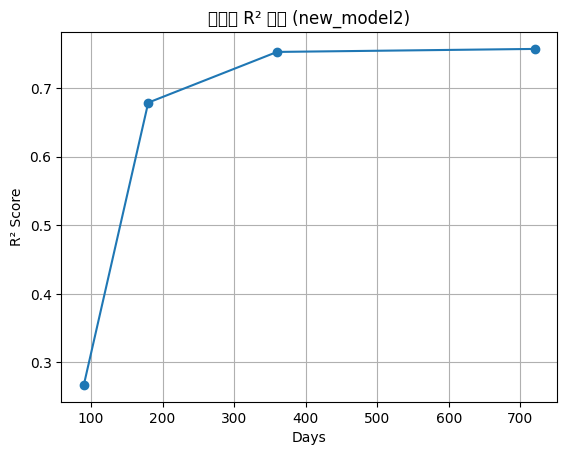

In [23]:
# new_model2: PRE_HANNNYU/scripts/new_model2 内のローカルモジュール利用 (再読込対応)
import sys, os, importlib
SCRIPT_ROOT = "/works/scripts"
if SCRIPT_ROOT not in sys.path:
    sys.path.append(SCRIPT_ROOT)
# 既存モジュールを再読込して最新パッチ反映
import new_model2.feature_builder as nm2_fb
import new_model2.predict_model_v4_2_4 as nm2_pred
importlib.reload(nm2_fb)
importlib.reload(nm2_pred)
from new_model2.predict_model_v4_2_4 import full_walkforward
from new_model2.feature_builder import WeatherFeatureBuilder, ReserveFeatureBuilder
from sklearn.metrics import r2_score, mean_absolute_error
import pandas as pd
import matplotlib.pyplot as plt

print('[INFO] using WeatherFeatureBuilder from', WeatherFeatureBuilder.__module__)

# 予約 raw データは df_reserve として既に存在 (列: 予約日, 予約得意先名, 固定客, 予約台数)
# 集計済み特徴量はここでは不要なので生成しない（full_walkforward 内で再度 ReserveFeatureBuilder を用いるため）
if not pd.api.types.is_datetime64_any_dtype(df_reserve['予約日']):
    df_reserve['予約日'] = pd.to_datetime(df_reserve['予約日'])

# 日付型保証
if not pd.api.types.is_datetime64_any_dtype(df_all["伝票日付"]):
    df_all["伝票日付"] = pd.to_datetime(df_all["伝票日付"])

# 評価対象の日数リスト
days_list = [90,180,360,720]  # 検証を速くするため一旦 1 パターン
results = []

for days in days_list:
    print(f"\n=== {days}日分のデータで評価中 (weather) ===")
    latest_date = df_all["伝票日付"].max()
    cutoff_date = latest_date - pd.Timedelta(days=days)
    df_subset = df_all[df_all["伝票日付"] >= cutoff_date].copy()
    hol_min = df_subset["伝票日付"].min()
    hol_max = df_subset["伝票日付"].max()
    print('[DEBUG] hol_min, hol_max =', hol_min, hol_max)
    holidays = get_japanese_holidays(hol_min, hol_max)

    # 予約 raw サブセット（列 予約日 でフィルタ）
    mask = (df_reserve['予約日'] >= hol_min) & (df_reserve['予約日'] <= hol_max)
    df_reserve_raw_subset = df_reserve.loc[mask].copy()
    print(f"[DEBUG] reserve_raw_rows={len(df_reserve_raw_subset)} range={df_reserve_raw_subset['予約日'].min()}->{df_reserve_raw_subset['予約日'].max() if len(df_reserve_raw_subset) else 'NA'}")

    # 天気特徴量取得
    weather_builder = WeatherFeatureBuilder(start_date=hol_min, end_date=hol_max, enable_fallback=True)
    df_weather_full = weather_builder.build()
    df_weather = df_weather_full.loc[hol_min:hol_max].copy() if not df_weather_full.empty else df_weather_full
    if len(df_weather) > 0:
        print(f"[DEBUG] weather_rows={len(df_weather)} range={df_weather.index.min()}->{df_weather.index.max()}")
    else:
        print("[DEBUG] weather empty (fallback or no data)")

    try:
        actual, pred = full_walkforward(
            df_raw=df_subset,
            df_reserve=df_reserve_raw_subset,  # 修正: raw を渡す
            holidays=holidays,
            df_weather=df_weather,
            min_stage1_days=30,
            min_stage2_days=15,
            top_n=2,
        )
        print(f"[DEBUG] returned_lengths actual={len(actual) if isinstance(actual,list) else 'NA'} pred={len(pred) if isinstance(pred,list) else 'NA'}")
        if isinstance(actual, list) and isinstance(pred, list) and len(actual) > 0 and len(pred) > 0:
            r2 = r2_score(actual, pred)
            mae = mean_absolute_error(actual, pred)
            results.append((days, r2, mae))
            print(f"✅ R² = {r2:.3f}, MAE = {mae:,.0f}kg")
        else:
            print("⚠ 評価に十分なデータがありません (予測件数0)")
            results.append((days, None, None))
    except Exception as e:
        print(f"❌ エラー: {e}")
        results.append((days, None, None))

# 結果表示
import pandas as pd

df_result = pd.DataFrame(results, columns=["days", "R2", "MAE"])
print("\n=== 評価結果 (new_model2) ===")
print(df_result)
if df_result["R2"].notna().any():
    plt.plot(df_result["days"], df_result["R2"], marker="o")
    plt.xlabel("Days")
    plt.ylabel("R² Score")
    plt.title("日数別 R² 評価 (new_model2)")
    plt.grid(True)
    plt.show()
else:
    print("R² 有効値が無いためプロットをスキップ")

In [18]:
# デバッグ: hol_min / hol_max の型確認用一時セル
print('sample hol_min/hol_max (from df_all tail)')
print(df_all['伝票日付'].tail(1), type(df_all['伝票日付'].iloc[-1]))

sample hol_min/hol_max (from df_all tail)
184249   2025-05-26
Name: 伝票日付, dtype: datetime64[ns] <class 'pandas._libs.tslibs.timestamps.Timestamp'>
